<a href="https://colab.research.google.com/github/Jayendar/Walmart-Retail-Sales-Analysis-Project/blob/main/Walmart_Retail_Sales_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Statement 1:
 A retail store that has multiple outlets across the country are facing issues in managing the
 inventory - to match the demand with respect to supply.
 Dataset Information:
 The walmart.csv contains 6435 rows and 8 columns.

In [ ]:
#loding all necessory libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from math import sqrt

import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

In [ ]:
#loading the dataset
df=pd.read_csv('Walmart DataSet.csv')
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [ ]:
#EDA
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


Data Pre-processing Steps and Inspiration
The Pre-processing of the data includes the following steps:

Data Cleaning: Cleaning the data by removing missing values, outliers and other inconsistencies.

Data Exploration: Exploring the data to gain insights and understanding the data on a deeper level.

Data Visualization: Visualizing the data for better understanding and understanding the patterns present.

In [ ]:
df.shape

(6435, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
# Converting 'Date' column to datetime and adding 'Year', 'Month' and 'Week' column

#df["Date"] = pd.to_datetime(df["Date"])
# df['Date'] = pd.to_datetime(df['Date'])
df["Date"] = pd.to_datetime(df["Date"], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
# df['Week'] = df['Date'].dt.week

In [ ]:
#Checking Duplicates

df.duplicated().sum()#no duplicates

0

In [ ]:
#check month wise weekly sales as weekly sales considerd to be target
df.groupby('Month')['Weekly_Sales'].mean()#month 1 has the highest sale

,Weekly_Sales
Month,
1.0,1.008661e+06
2.0,1.070976e+06
3.0,1.064208e+06
4.0,1.062676e+06
5.0,1.057717e+06
6.0,1.087901e+06
7.0,1.037893e+06
8.0,1.047227e+06
9.0,1.089198e+06


In [ ]:
#check year wise weekly sales
df.groupby('Year')['Weekly_Sales'].mean()

,Weekly_Sales
Year,
2010.0,1.064298e+06
2011.0,1.049375e+06
2012.0,1.068118e+06


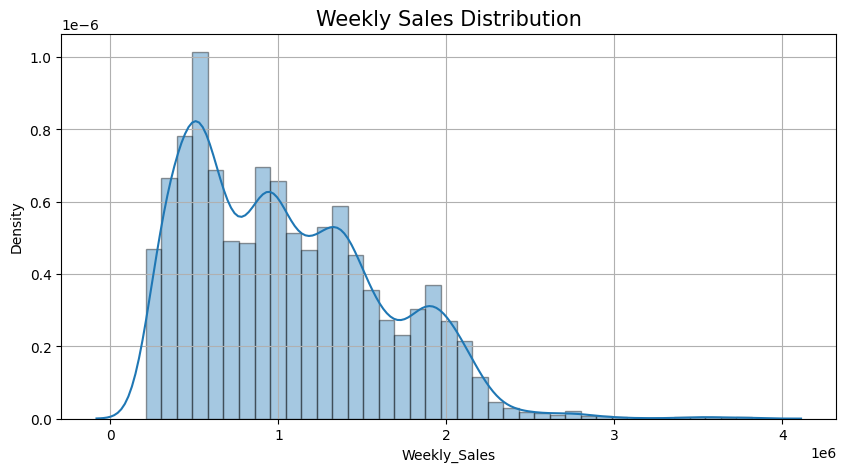

In [ ]:
# Data Visualization

# Analyzing the distribution of target variable
plt.figure(figsize = (10, 5))
sns.distplot(df['Weekly_Sales'], hist_kws=dict(edgecolor="black"))
plt.title('Weekly Sales Distribution', fontsize= 15)
plt.grid()
plt.show()

In [ ]:
#0 to first month has the highest sale

In [ ]:
df['Holiday_Flag'].value_counts()

,count
Holiday_Flag,
0,5985
1,450


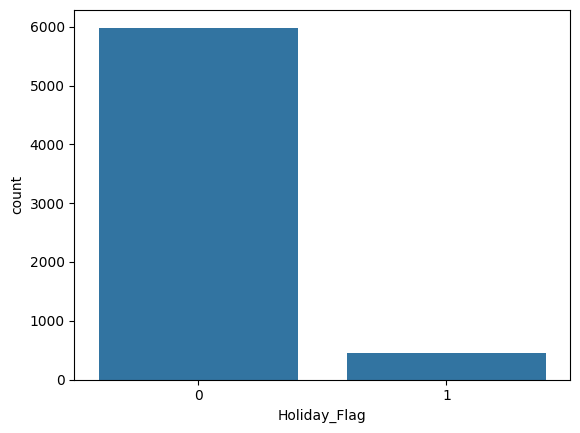

In [ ]:
sns.countplot(x = 'Holiday_Flag', data =df);

weekly sales is 33% more during holidays.

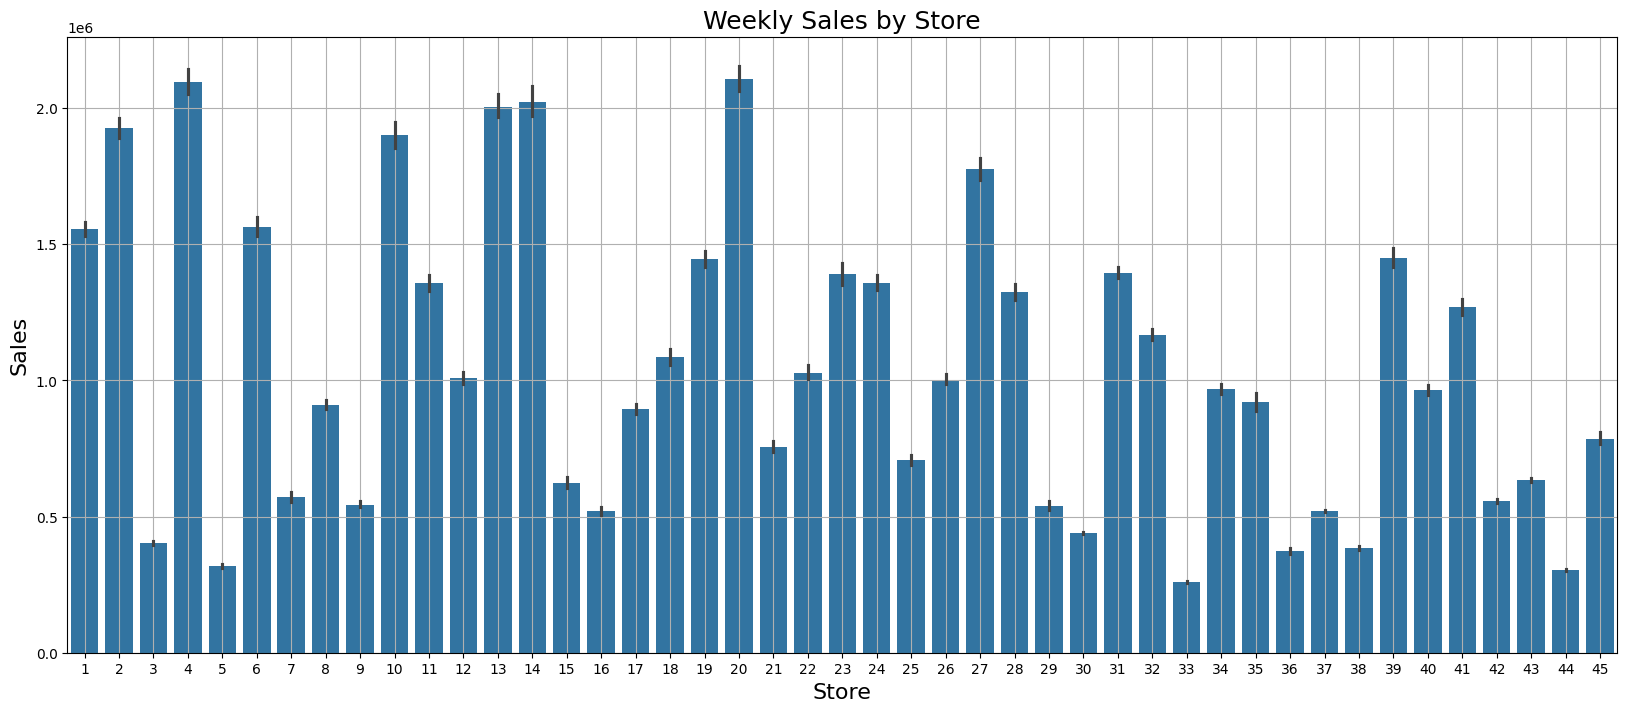

In [ ]:
#store wise sales performance
plt.figure(figsize=(20,8))
sns.barplot(x=df['Store'], y=df['Weekly_Sales'])
plt.title('Weekly Sales by Store', fontsize=18)
plt.ylabel('Sales', fontsize=16)
plt.xlabel('Store', fontsize=16)
plt.grid()
plt.show()

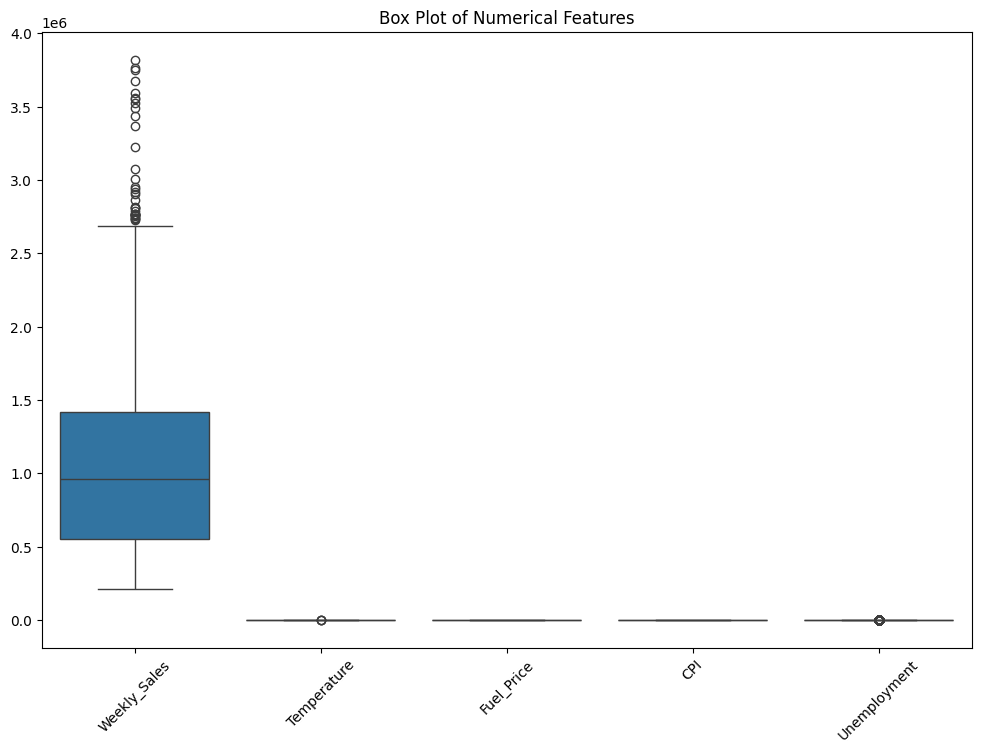

Number of outliers removed: 251


In [ ]:
#checking for outliers

# Box plot for numerical features
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']])
plt.title('Box Plot of Numerical Features')
plt.xticks(rotation=45)
plt.show()

# Z-score outlier detection
from scipy import stats

numerical_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
z_scores = stats.zscore(df[numerical_cols])
abs_z_scores = abs(z_scores)
filtered_entries = (abs_z_scores < 3).all(axis=1)
df_no_outliers = df[filtered_entries]

print("Number of outliers removed:", len(df) - len(df_no_outliers))


more outliers present in weekly sales. removing outliers for inferences

 a. If the weekly sales are affected by the unemployment rate, if yes - which stores
 are suffering the most?

In [ ]:
# Calculate correlation between weekly sales and unemployment rate for each store
correlation_by_store = df.groupby('Store')[['Weekly_Sales', 'Unemployment']].corr().reset_index()
correlation_by_store.rename(columns={'Unemployment': 'Correlation'}, inplace=True)

# Identify stores suffering the most (highest negative correlation)
stores_suffering_most = correlation_by_store.sort_values(by='Correlation', ascending=True)['Store'].head(5)

print("Stores suffering the most due to unemployment rate:")
print(stores_suffering_most)


Stores suffering the most due to unemployment rate:
74    38
86    44
76    39
82    42
80    41
Name: Store, dtype: int64


b. If the weekly sales show a seasonal trend, when and what could be the reason?

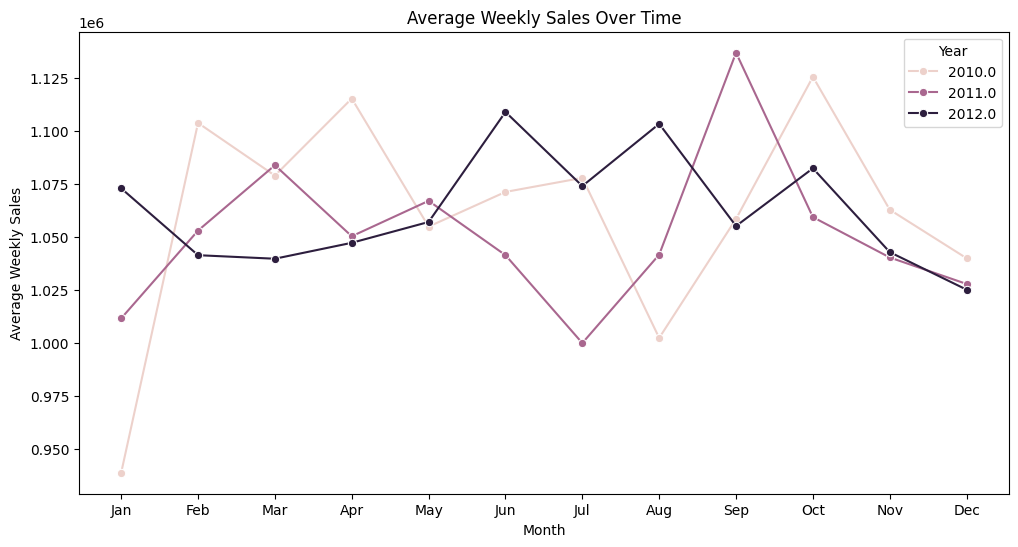

In [ ]:
# Group by month and year, calculate average weekly sales
average_sales_by_month = df.groupby(['Year', 'Month'])['Weekly_Sales'].mean().reset_index()

# Plot average weekly sales over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=average_sales_by_month, x='Month', y='Weekly_Sales', hue='Year', marker='o')
plt.title('Average Weekly Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year', loc='upper right')
plt.show()


sales is increasing in the beginning of every new season, reaon may be seasonal requirments

c. Does temperature affect the weekly sales in any manner?

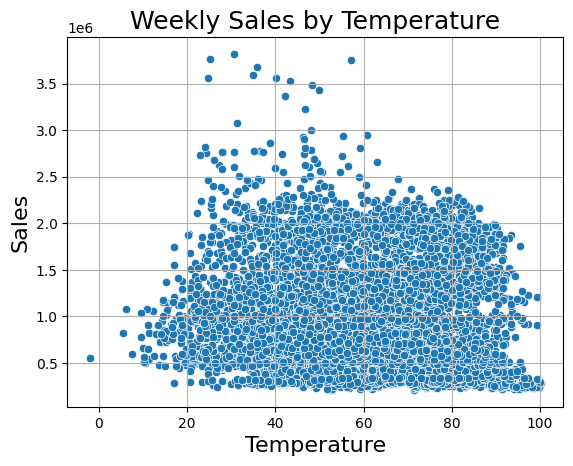

In [ ]:


#plt.figure(figsize=(20,8))
sns.scatterplot(x=df['Temperature'], y=df['Weekly_Sales'])
plt.title('Weekly Sales by Temperature', fontsize=18)
plt.ylabel('Sales', fontsize=16)
plt.xlabel('Temperature', fontsize=16)
plt.grid()
plt.show()



Temperature effect is not much impacting on weekly sales

d. How is the Consumer Price index affecting the weekly sales of various stores?

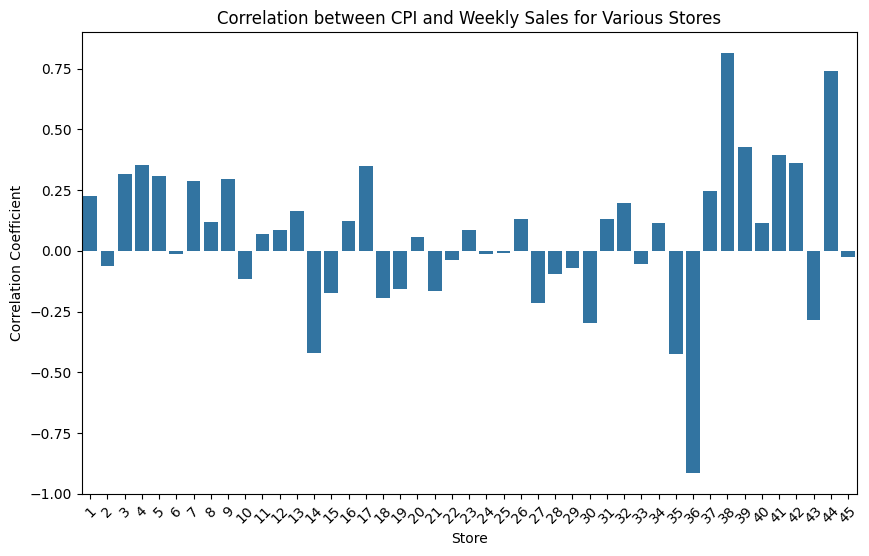

In [ ]:


# Handle missing values
df.fillna(method='ffill', inplace=True)  # Forward fill missing values

# Calculate correlation coefficient between CPI and weekly sales for each store
correlation_by_store = df.groupby('Store').apply(lambda x: x['CPI'].corr(x['Weekly_Sales'])).reset_index()
correlation_by_store.columns = ['Store', 'Correlation']

# Create a bar plot for correlation
plt.figure(figsize=(10, 6))
sns.barplot(data=correlation_by_store, x='Store', y='Correlation')
plt.title('Correlation between CPI and Weekly Sales for Various Stores')
plt.xlabel('Store')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)
plt.show()


This bar plot will visually represent how the CPI affects the weekly sales of various stores. Positive correlation coefficients indicate a positive relationship, negative correlation coefficients indicate a negative relationship, and correlation coefficients close to zero indicate a weak or no relationship. Adjust the code based on your specific dataset and requirements.






e. Top performing stores according to the historical data.

In [ ]:

# Calculate total weekly sales for each store
total_sales_by_store = df.groupby('Store')['Weekly_Sales'].sum().reset_index()

# Sort stores by total sales in descending order to identify top performers
top_performing_stores = total_sales_by_store.sort_values(by='Weekly_Sales', ascending=False)

# Display top performing stores
print("Top performing stores according to historical data:")
print(top_performing_stores.head())


Top performing stores according to historical data:
    Store  Weekly_Sales
19     20  3.013978e+08
3       4  2.995440e+08
13     14  2.889999e+08
12     13  2.865177e+08
1       2  2.753824e+08


 f.
 The worst performing store, and how significant is the difference between the
 highest and lowest performing stores.

In [ ]:
import pandas as pd

# Calculate total weekly sales for each store
total_sales_by_store = df.groupby('Store')['Weekly_Sales'].sum().reset_index()

# Sort stores by total sales to identify the worst performing store
worst_performing_store = total_sales_by_store.sort_values(by='Weekly_Sales').iloc[0]

# Sort stores by total sales in descending order to identify the top performing store
top_performing_store = total_sales_by_store.sort_values(by='Weekly_Sales', ascending=False).iloc[0]

# Calculate the difference in sales between the highest and lowest performing stores
difference = top_performing_store['Weekly_Sales'] - worst_performing_store['Weekly_Sales']

# Display the worst performing store and the difference in sales
print("Worst performing store:")
print(worst_performing_store)
print("\nDifference between highest and lowest performing stores:", difference)


Worst performing store:
Store                 33.00
Weekly_Sales    37160221.96
Name: 32, dtype: float64

Difference between highest and lowest performing stores: 264237570.49999997


 2. Use predictive modeling techniques to forecast the sales for each store for the next 12
 weeks

In [ ]:
data = pd.read_csv('Walmart DataSet.csv')
data.set_index('Date', inplace=True)
# Selecting one particular store from the dataset
a= int(input("Enter store id: "))
store = data1[data1.Store == a]
sales = pd.DataFrame(store.Weekly_Sales.groupby(store.index).sum())
sales.dtypes

Enter store id: 25


,0
Weekly_Sales,float64


In [ ]:
sales.head(20)

,Date,Weekly_Sales
0,01-04-2011,618377.79
1,01-06-2012,694765.95
2,01-07-2011,706206.86
3,01-10-2010,658640.14
4,02-03-2012,643155.89
5,02-04-2010,822486.37
6,02-07-2010,759407.87
7,02-09-2011,699779.00
8,02-12-2011,878314.57
9,03-02-2012,642776.40


In [ ]:
#Date is to acceptable, remove date from index to change its dtype.
sales.reset_index(inplace = True)
#converting 'date' column to a datetime type
sales['Date'] = pd.to_datetime(sales['Date'])
# resetting date back to the index
sales.set_index('Date',inplace = True)

ValueError: time data "13-01-2012" doesn't match format "%m-%d-%Y", at position 57. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

Choosing the Algorithm for the Project
The choice of algorithm for a machine learning project is depends upon the type of problem we are trying to solve.As given dataset contains target column with numeric continious data, supervised machine learning algorithems like linear regression, descion tree,random forest are implemented to check the performnce of the target variable.

In [ ]:
x = df.drop(['Date','Weekly_Sales'], axis=1)
x

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month
0,1,0,42.31,2.572,211.096358,8.106,2010.0,5.0
1,1,1,38.51,2.548,211.242170,8.106,2010.0,12.0
2,1,0,39.93,2.514,211.289143,8.106,2010.0,12.0
3,1,0,46.63,2.561,211.319643,8.106,2010.0,12.0
4,1,0,46.50,2.625,211.350143,8.106,2010.0,5.0
...,...,...,...,...,...,...,...,...
6430,45,0,64.88,3.997,192.013558,8.684,2012.0,7.0
6431,45,0,64.89,3.985,192.170412,8.667,2012.0,5.0
6432,45,0,54.47,4.000,192.327265,8.667,2012.0,12.0
6433,45,0,56.47,3.969,192.330854,8.667,2012.0,12.0


In [ ]:
y = df['Weekly_Sales']


Linear Regression:

Accuracy: 14.406570863519597
Mean Absolute Error: 425451.5328082225
Mean Squared Error: 271179766770.17734
Root Mean Squared Error: 520749.2359765661


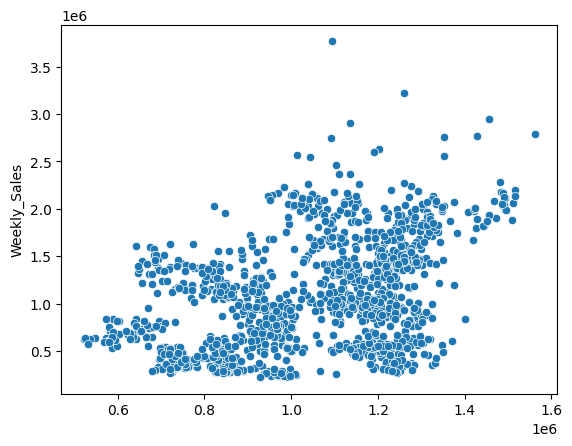

In [ ]:
print('Linear Regression:')
print()

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=99)

reg = LinearRegression()
reg.fit(X_train, Y_train)
Y_pred = reg.predict(X_test)
print('Accuracy:',reg.score(X_train, Y_train)*100)
print('Mean Absolute Error:', metrics.mean_absolute_error(Y_test, Y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(Y_test, Y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))
sns.scatterplot(x=Y_pred, y=Y_test)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
rf = RandomForestRegressor(n_estimators = 100)
rf.fit(x, y)

RandomForestRegressor()

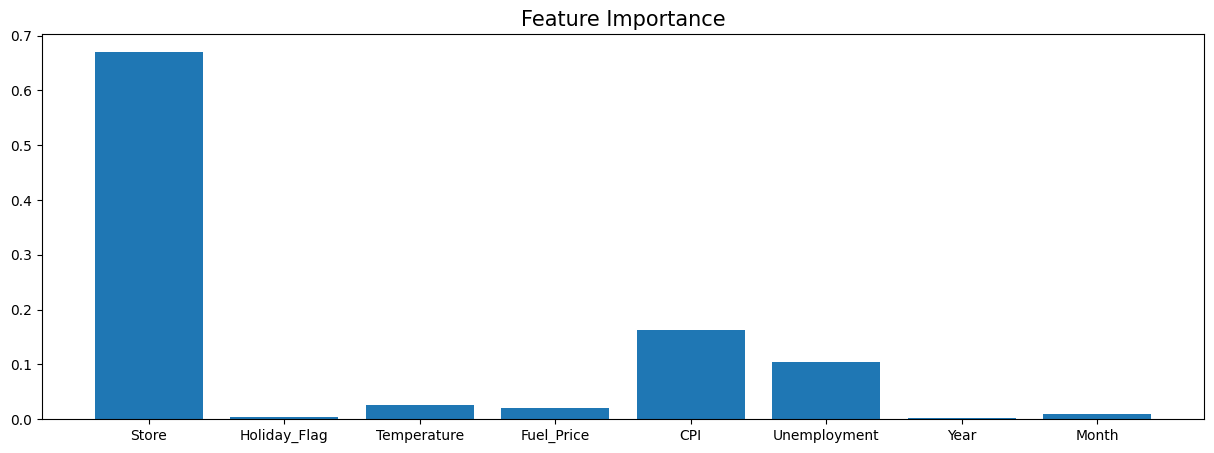

In [ ]:
# checking the feature importance

plt.figure(figsize = (15, 5))
plt.bar(x.columns, rf.feature_importances_)
plt.title("Feature Importance", fontsize = 15)
plt.show()

otherthan store operations little bit CPI, unemployment and week parameters are impacting on sales

Random Forest Regressor:

Accuracy: 93.94798066768625
Mean Absolute Error: 75513.72337925405
Mean Squared Error: 19093940357.892185
Root Mean Squared Error: 138180.82485602764


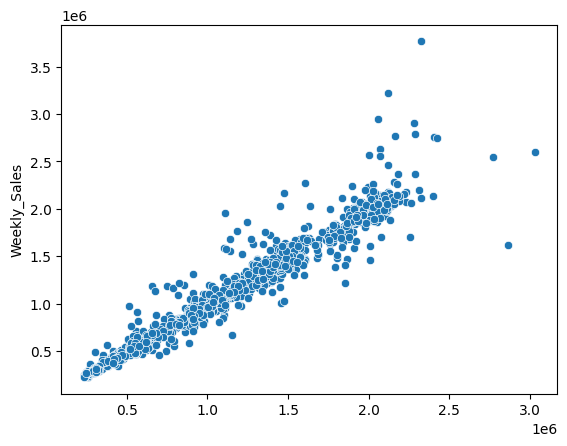

In [ ]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
print('Random Forest Regressor:')
print()
rfr = RandomForestRegressor()
rfr.fit(X_train,Y_train)
Y_pred = rfr.predict(X_test)
print('Accuracy:',rfr.score(X_test, Y_test)*100)
print('Mean Absolute Error:', metrics.mean_absolute_error(Y_test, Y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(Y_test, Y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))
sns.scatterplot(x=Y_pred, y=Y_test)


import warnings
warnings.filterwarnings('ignore')

Here, Linear Regression is not an appropriate model to use which is clear from it's low accuracy. However, Random Forest Regression gives accuracy of over 93% , so, it is the best model to forecast demand.